# Multi-SpaCE Ablation Study

This notebook reads the detailed per-instance `metrics` sheet from every experiment hash workbook, rebuilds hash-level averages from those rows, and then analyzes which parameter combination is best as a general rule across datasets. The stability views intentionally keep dataset-level results visible so a globally good setting does not hide dataset-specific failures.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", context="notebook")


def find_evaluation_dir(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        evaluation_dir = candidate / "experiments" / "evaluation"
        if evaluation_dir.is_dir():
            return evaluation_dir
    if start.name == "evaluation":
        return start
    raise FileNotFoundError(f"Could not find experiments/evaluation from {start}")


EVALUATION_DIR = find_evaluation_dir()
if str(EVALUATION_DIR) not in sys.path:
    sys.path.insert(0, str(EVALUATION_DIR))

from ablation_analysis_utils import (
    add_parameter_combination,
    aggregate_combination_rule,
    combination_metric_table,
    dataset_combination_means,
    find_results_root,
    infer_parameter_columns,
    load_instance_metrics,
    parameter_heatmap_data,
    rank_combinations_across_datasets,
    summarize_hash_metrics,
)


## Configuration

Change `EXPERIMENT_FAMILIES`, `DATASETS`, `PRIMARY_METRIC`, or the selected parameters here. Leave `PARAMETERS_TO_ANALYZE = None` to infer the varying config parameters from the detailed files.


In [2]:
RESULTS_ROOT = find_results_root()
MODEL_TO_EXPLAIN = "inceptiontime_noscaling"
EXPERIMENT_FAMILIES = ["multisubspace_v2_ip_global_ec_mutation"]
WEIGHTS_FILE = "model_weights_10_28_42_20.xlsx"

DATASETS = [
    "BasicMotions",
    "NATOPS",
    "UWaveGestureLibrary",
    "ArticularyWordRecognition",
    "Epilepsy",
    "PenDigits",
    "RacketSports",
    "SelfRegulationSCP1",
]

PRIMARY_METRIC = "IoN"
HIGHER_IS_BETTER = True

# These are metrics already present in the detailed per-instance sheet.
# Hash-level means/stds/medians are recalculated from these rows below.
METRIC_COLUMNS = [
    "IoN",
    "valid",
    "selected utility score",
    "proximity",
    "sparsity",
    "NoS",
    "AE_OS",
    "IF_OS",
    "LOF_OS",
    "subsequences",
    "subsequences %",
    "(sparsity + subsequences %) / 2",
    "times",
    "L2",
    "proba",
]

# Keep this as None to infer only config columns with more than one value.
PARAMETERS_TO_ANALYZE = ["change_subseq_mutation_prob", "channel_mutation_prob"]

# If None, the parameter-combination label uses every inferred parameter.
COMBINATION_PARAMETERS = ["change_subseq_mutation_prob", "channel_mutation_prob"]

# The heatmap is for the average hash-level PRIMARY_METRIC over two selected parameters.
HEATMAP_PARAMETERS = ["change_subseq_mutation_prob", "channel_mutation_prob"]

BOXPLOT_METRIC = "IoN_mean"
TOP_N_HASHES_PER_DATASET = 5

INSTANCE_LEVEL_COLUMNS_TO_EXCLUDE = {
    "ii",
    "best cf index",
    "pred_class",
    "target_class",
    "original_class",
    "true_class",
    "counterfactuals_path",
    "metrics_excel_path",
}


## Load Detailed Experiment Rows

This is the main reframing: the notebook reads every hash workbook's `metrics` sheet and attaches the config parameters from `params.json` or the workbook `params` sheet. Nothing below depends on the precomputed family summaries.


In [3]:
instance_metrics = load_instance_metrics(
    RESULTS_ROOT,
    MODEL_TO_EXPLAIN,
    EXPERIMENT_FAMILIES,
    datasets=DATASETS,
    weights_file=WEIGHTS_FILE,
)

# print(instance_metrics.shape)
# display(instance_metrics.head())


## Recalculate Hash-Level Metrics

Each row below is one experiment hash. Means, standard deviations, and medians are recalculated directly from the detailed per-instance rows.


In [4]:
if PARAMETERS_TO_ANALYZE is None:
    PARAMETERS_TO_ANALYZE = infer_parameter_columns(
        instance_metrics,
        METRIC_COLUMNS,
        extra_exclude=INSTANCE_LEVEL_COLUMNS_TO_EXCLUDE,
    )

COMBINATION_PARAMETERS = PARAMETERS_TO_ANALYZE if COMBINATION_PARAMETERS is None else COMBINATION_PARAMETERS
HEATMAP_PARAMETERS = tuple(PARAMETERS_TO_ANALYZE[:2]) if HEATMAP_PARAMETERS is None and len(PARAMETERS_TO_ANALYZE) >= 2 else HEATMAP_PARAMETERS

print("Parameters:", PARAMETERS_TO_ANALYZE)
print("Combination parameters:", COMBINATION_PARAMETERS)
print("Heatmap parameters:", HEATMAP_PARAMETERS)

hash_metrics = summarize_hash_metrics(instance_metrics, METRIC_COLUMNS, PARAMETERS_TO_ANALYZE)
hash_metrics = add_parameter_combination(hash_metrics, COMBINATION_PARAMETERS)

primary_mean_col = f"{PRIMARY_METRIC}_mean"


Parameters: ['change_subseq_mutation_prob', 'channel_mutation_prob']
Combination parameters: ['change_subseq_mutation_prob', 'channel_mutation_prob']
Heatmap parameters: ['change_subseq_mutation_prob', 'channel_mutation_prob']


In [5]:
hash_metrics.groupby(["parameter_combination", "experiment_hash"])["IoN_mean"].mean()

parameter_combination                                          experiment_hash                            
change_subseq_mutation_prob=0.1 | channel_mutation_prob=0      v2_6d12a71f58beaa23e72257086107d85041d59c0f    0.157802
change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.05   v2_aaddaf56a64c23d44fec9ed11f2a7b9516501209    0.226073
change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.1    v2_f59dab09e8b17973e905e25d9bc93ef6ee15fd56    0.226224
change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.25   v2_e23562c6d6de34614f2ce59e5c24605f3cdd38c0    0.213454
change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.5    v2_b26df68e14469490622057a54eaf6ac96454921f    0.130886
change_subseq_mutation_prob=0.25 | channel_mutation_prob=0     v2_ffca771bc787c23078668af05ce6c8aee1b09e57    0.164481
change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.05  v2_6c8302e2dc07d6d87a3745b996e71bd736dd57da    0.234848
change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.1

## Best General Parameter Combination

The ranking below first averages hashes inside each dataset/parameter-combination, then ranks combinations by the mean of those dataset means. This gives each dataset equal weight in the final rule, instead of letting datasets with more rows dominate.


In [6]:
dataset_combo = dataset_combination_means(hash_metrics, primary_mean_col)
dataset_combo = rank_combinations_across_datasets(
    dataset_combo,
    f"{primary_mean_col}_dataset_mean",
    higher_is_better=HIGHER_IS_BETTER,
)

combination_ranking = aggregate_combination_rule(
    dataset_combo,
    f"{primary_mean_col}_dataset_mean",
    higher_is_better=HIGHER_IS_BETTER,
)

ranked_combo_table = combination_metric_table(
    dataset_combo,
    f"{primary_mean_col}_dataset_mean",
)

ranked_combo_rank_table = combination_metric_table(
    dataset_combo,
    "dataset_rank",
)

display(combination_ranking)
display(ranked_combo_table)
display(ranked_combo_rank_table)


,parameter_combination,mean_across_dataset_means,stability_std_across_datasets,median_across_dataset_means,n_datasets,overall_rank
0,change_subseq_mutation_prob=0.5 | channel_muta...,0.236103,0.035521,0.232712,8,1
1,change_subseq_mutation_prob=0.5 | channel_muta...,0.236075,0.034392,0.232627,8,2
2,change_subseq_mutation_prob=0.25 | channel_mut...,0.235149,0.034062,0.233022,8,3
3,change_subseq_mutation_prob=0.25 | channel_mut...,0.234848,0.035554,0.232819,8,4
4,change_subseq_mutation_prob=0.75 | channel_mut...,0.234049,0.036659,0.231954,8,5
5,change_subseq_mutation_prob=0.75 | channel_mut...,0.233452,0.036687,0.229198,8,6
6,change_subseq_mutation_prob=0.5 | channel_muta...,0.231258,0.032781,0.231813,8,7
7,change_subseq_mutation_prob=0.25 | channel_mut...,0.227746,0.033603,0.225465,8,8
8,change_subseq_mutation_prob=0.1 | channel_muta...,0.226224,0.037298,0.224521,8,9
9,change_subseq_mutation_prob=0.1 | channel_muta...,0.226073,0.037596,0.224669,8,10


parameter_combination,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.5
dataset,,,,,,,,,,,,,,,,,,,,,,,,,
ArticularyWordRecognition,0.138879,0.219169,0.220229,0.209417,0.171476,0.143332,0.225337,0.225649,0.217525,0.194817,0.144830,0.226757,0.226722,0.222761,0.198399,0.143828,0.225321,0.224639,0.219016,0.175081,0.139379,0.219193,0.219527,0.206439,0.100062
BasicMotions,0.122700,0.230170,0.228814,0.223549,0.200574,0.130671,0.240302,0.240394,0.236039,0.220658,0.130332,0.238666,0.238532,0.240865,0.232987,0.128234,0.233076,0.239269,0.233242,0.215385,0.128150,0.226126,0.225721,0.223001,0.184757
Epilepsy,0.104568,0.178934,0.181661,0.164088,-0.031218,0.115319,0.197327,0.199049,0.189988,0.035799,0.121013,0.200282,0.202688,0.195447,0.072816,0.116628,0.196705,0.196895,0.191204,0.014531,0.109241,0.183245,0.182400,0.130916,-0.050637
NATOPS,0.206839,0.289167,0.289591,0.281459,0.267033,0.207326,0.291721,0.288992,0.280954,0.268027,0.207473,0.289943,0.288685,0.281629,0.269207,0.207532,0.290105,0.289702,0.282093,0.268680,0.207077,0.288357,0.287922,0.282891,0.264484
PenDigits,0.166590,0.203629,0.205834,0.209427,0.208098,0.167154,0.203789,0.209374,0.206285,0.204643,0.166593,0.203999,0.203959,0.204690,0.202307,0.165396,0.199105,0.198900,0.199339,0.199662,0.164633,0.191258,0.194595,0.196049,0.195496
RacketSports,0.207191,0.263920,0.266907,0.267504,0.265573,0.207260,0.264152,0.265495,0.267478,0.263773,0.207401,0.264899,0.265635,0.267148,0.263925,0.206982,0.263880,0.264723,0.266056,0.264659,0.206344,0.265319,0.264628,0.266383,0.262983
SelfRegulationSCP1,0.188930,0.237127,0.230590,0.194046,0.153185,0.205016,0.261024,0.258159,0.233405,0.180004,0.209391,0.268643,0.265474,0.243582,0.193451,0.208614,0.266194,0.265112,0.231288,0.164719,0.190464,0.244117,0.234997,0.198078,0.135115
UWaveGestureLibrary,0.126721,0.186472,0.186168,0.158145,-0.187633,0.139771,0.195128,0.194078,0.190293,-0.039797,0.139865,0.195635,0.196908,0.193944,-0.007800,0.137976,0.193229,0.193150,0.179667,-0.071895,0.131132,0.187495,0.186443,0.091276,-0.253020


parameter_combination,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.5
dataset,,,,,,,,,,,,,,,,,,,,,,,,,
ArticularyWordRecognition,24.0,11.0,8.0,14.0,19.0,22.0,4.0,3.0,13.0,17.0,20.0,1.0,2.0,7.0,16.0,21.0,5.0,6.0,12.0,18.0,23.0,10.0,9.0,15.0,25.0
BasicMotions,25.0,11.0,12.0,15.0,19.0,21.0,3.0,2.0,7.0,17.0,22.0,5.0,6.0,1.0,10.0,23.0,9.0,4.0,8.0,18.0,24.0,13.0,14.0,16.0,20.0
Epilepsy,20.0,13.0,12.0,14.0,24.0,18.0,4.0,3.0,9.0,22.0,16.0,2.0,1.0,7.0,21.0,17.0,6.0,5.0,8.0,23.0,19.0,10.0,11.0,15.0,25.0
NATOPS,25.0,6.0,5.0,14.0,19.0,23.0,1.0,7.0,15.0,18.0,22.0,3.0,8.0,13.0,16.0,21.0,2.0,4.0,12.0,17.0,24.0,9.0,10.0,11.0,20.0
PenDigits,23.0,11.0,5.0,1.0,3.0,21.0,10.0,2.0,4.0,7.0,22.0,8.0,9.0,6.0,12.0,24.0,15.0,16.0,14.0,13.0,25.0,20.0,19.0,17.0,18.0
RacketSports,23.0,17.0,4.0,1.0,8.0,22.0,15.0,9.0,2.0,19.0,21.0,11.0,7.0,3.0,16.0,24.0,18.0,12.0,6.0,13.0,25.0,10.0,14.0,5.0,20.0
SelfRegulationSCP1,21.0,9.0,13.0,18.0,24.0,16.0,5.0,6.0,11.0,22.0,14.0,1.0,3.0,8.0,19.0,15.0,2.0,4.0,12.0,23.0,20.0,7.0,10.0,17.0,25.0
UWaveGestureLibrary,19.0,10.0,12.0,14.0,24.0,16.0,3.0,4.0,8.0,22.0,15.0,2.0,1.0,5.0,21.0,17.0,6.0,7.0,13.0,23.0,18.0,9.0,11.0,20.0,25.0


## Stability Views

These views show whether the best global combination is consistently strong or unstable across datasets.


/tmp/ipykernel_3958831/1687997428.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


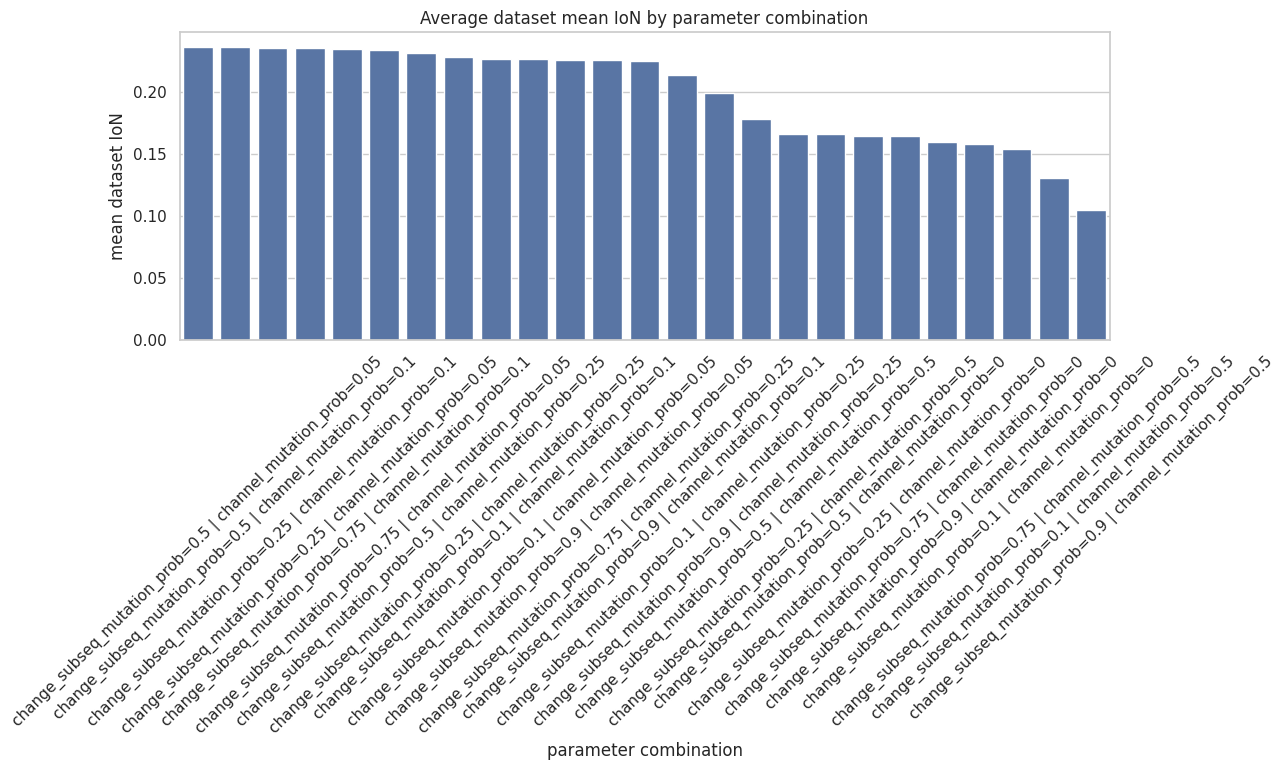

In [7]:
plt.figure(figsize=(12, 4))
ax = sns.barplot(
    data=combination_ranking,
    x="parameter_combination",
    y="mean_across_dataset_means",
    errorbar=None,
)
ax.set_title(f"Average dataset mean {PRIMARY_METRIC} by parameter combination")
ax.set_xlabel("parameter combination")
ax.set_ylabel(f"mean dataset {PRIMARY_METRIC}")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_3958831/4200588280.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


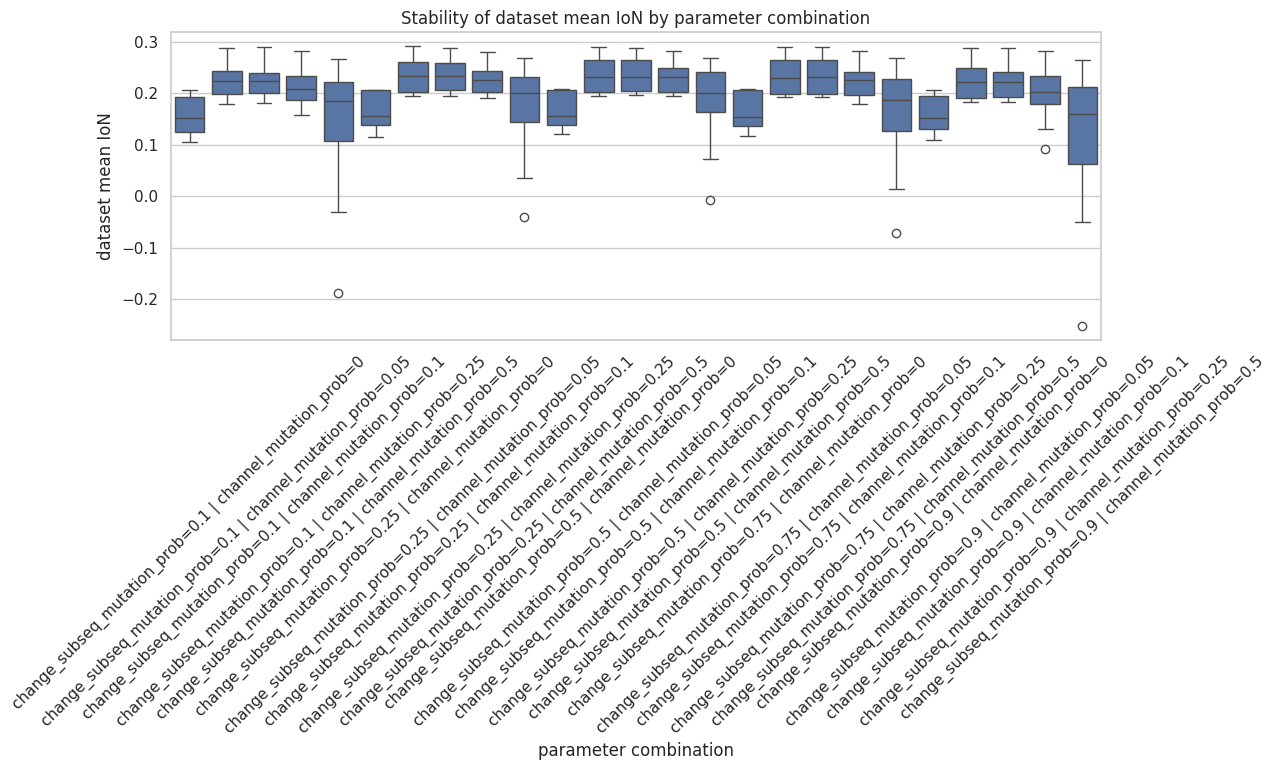

In [8]:
plt.figure(figsize=(12, 4))
ax = sns.boxplot(
    data=dataset_combo,
    x="parameter_combination",
    y=f"{primary_mean_col}_dataset_mean",
)
ax.set_title(f"Stability of dataset mean {PRIMARY_METRIC} by parameter combination")
ax.set_xlabel("parameter combination")
ax.set_ylabel(f"dataset mean {PRIMARY_METRIC}")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Two-Parameter Heatmap

Set `HEATMAP_PARAMETERS = ("param_x", "param_y")` in the config cell to choose the axes. The values are averages of hash-level means.


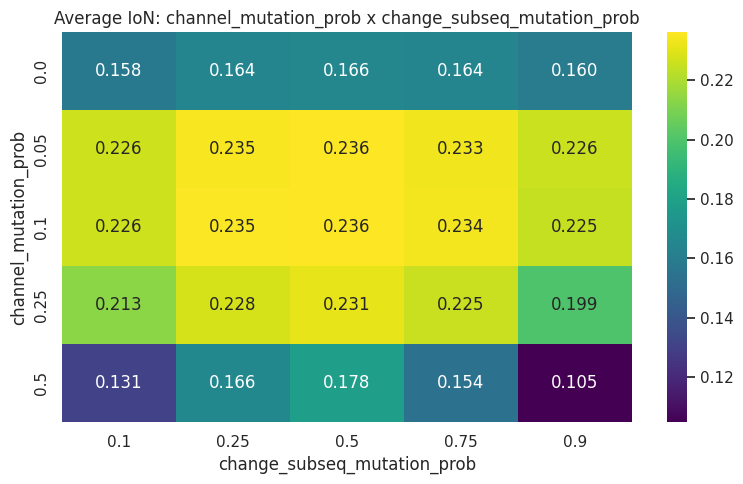

change_subseq_mutation_prob,0.10,0.25,0.50,0.75,0.90
channel_mutation_prob,,,,,
0.00,0.157802,0.164481,0.165862,0.164399,0.159553
0.05,0.226073,0.234848,0.236103,0.233452,0.225639
0.10,0.226224,0.235149,0.236075,0.234049,0.224529
0.25,0.213454,0.227746,0.231258,0.225238,0.199379
0.50,0.130886,0.165990,0.178162,0.153853,0.104905


In [9]:
if HEATMAP_PARAMETERS is not None:
    heatmap_x, heatmap_y = HEATMAP_PARAMETERS
    if heatmap_x in hash_metrics.columns and heatmap_y in hash_metrics.columns:
        heatmap_df = parameter_heatmap_data(hash_metrics, heatmap_x, heatmap_y, primary_mean_col)
        plt.figure(figsize=(8, 5))
        ax = sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="viridis")
        ax.set_title(f"Average {PRIMARY_METRIC}: {heatmap_y} x {heatmap_x}")
        plt.tight_layout()
        plt.show()
        display(heatmap_df)
    else:
        print(f"Missing heatmap parameters: {HEATMAP_PARAMETERS}")


## Dataset Boxplot by Parameter Combination

Use this cell as a local control panel: choose the metric here, and optionally filter to only one value of one parameter before plotting. This avoids rerunning the whole notebook just to inspect another metric or slice.


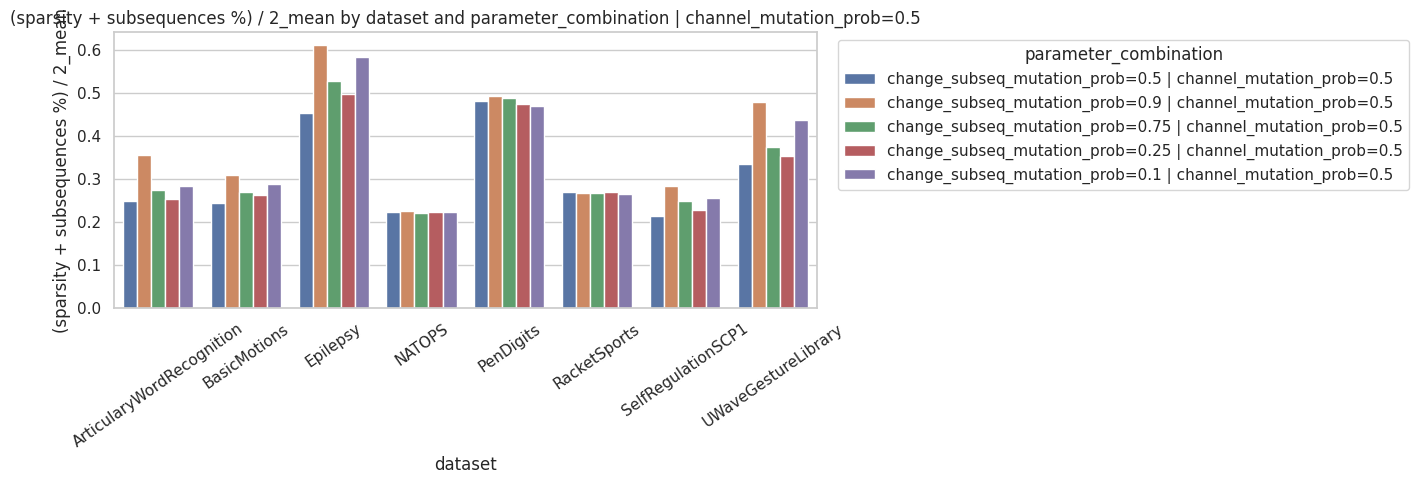

Rows plotted: 40


In [15]:
# Local controls for this plot. Change these and rerun only this cell.
PLOT_METRIC = "NoS_mean"
PLOT_METRIC = "(sparsity + subsequences %) / 2_mean"

# Optional filter. Example:
PLOT_FILTER_PARAMETER = "channel_mutation_prob"
PLOT_FILTER_VALUE = 0.5
# PLOT_FILTER_PARAMETER = None
# PLOT_FILTER_VALUE = None

# Hue can be the full parameter combination or a single parameter.
# A single parameter is usually easier to read when filtering by another parameter value.
PLOT_HUE = "parameter_combination"
# PLOT_HUE = "channel_mutation_prob"
# PLOT_HUE = "change_subseq_mutation_prob"

plot_metric = PLOT_METRIC if PLOT_METRIC in hash_metrics.columns else primary_mean_col
plot_df = hash_metrics.copy()

if PLOT_FILTER_PARAMETER is not None and PLOT_FILTER_VALUE is not None:
    if PLOT_FILTER_PARAMETER not in plot_df.columns:
        raise KeyError(f"Unknown filter parameter: {PLOT_FILTER_PARAMETER}")
    plot_df = plot_df[plot_df[PLOT_FILTER_PARAMETER].astype(str).eq(str(PLOT_FILTER_VALUE))]

if PLOT_HUE not in plot_df.columns:
    raise KeyError(f"Unknown hue column: {PLOT_HUE}")

plt.figure(figsize=(14, 5))
ax = sns.barplot(
    data=plot_df,
    x="dataset",
    y=plot_metric,
    hue=PLOT_HUE,
)
filter_text = ""
if PLOT_FILTER_PARAMETER is not None and PLOT_FILTER_VALUE is not None:
    filter_text = f" | {PLOT_FILTER_PARAMETER}={PLOT_FILTER_VALUE}"
ax.set_title(f"{plot_metric} by dataset and {PLOT_HUE}{filter_text}")
ax.set_xlabel("dataset")
ax.set_ylabel(plot_metric)
ax.tick_params(axis="x", rotation=35)
ax.legend(title=PLOT_HUE, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(f"Rows plotted: {len(plot_df)}")


## Dataset x Parameter Tables

Choose the metric locally here too. Rows are datasets and columns are either full parameter combinations or one selected parameter. Optional filtering lets you inspect one fixed value of another parameter.


In [14]:
# Local controls for these tables. Change these and rerun only this cell.
TABLE_METRIC = "IoN_mean"
TABLE_HIGHER_IS_BETTER = True

# Column choices:
# - "parameter_combination" shows every full parameter combination, as before.
# - a single parameter name shows only that parameter's values.
# - a list/tuple of parameters shows every combination of that selected subset.
TABLE_COLUMNS = "parameter_combination"
# TABLE_COLUMNS = "channel_mutation_prob"
# TABLE_COLUMNS = "change_subseq_mutation_prob"
# TABLE_COLUMNS = ["change_subseq_mutation_prob", "channel_mutation_prob"]

# Optional filter. You can still keep TABLE_COLUMNS = "parameter_combination"
# to inspect every remaining full combination after applying this filter.
# Example:
# TABLE_FILTER_PARAMETER = "channel_mutation_prob"
# TABLE_FILTER_VALUE = 0.1
TABLE_FILTER_PARAMETER = None
TABLE_FILTER_VALUE = None

table_metric = TABLE_METRIC if TABLE_METRIC in hash_metrics.columns else primary_mean_col
table_df = hash_metrics.copy()

if TABLE_FILTER_PARAMETER is not None and TABLE_FILTER_VALUE is not None:
    if TABLE_FILTER_PARAMETER not in table_df.columns:
        raise KeyError(f"Unknown filter parameter: {TABLE_FILTER_PARAMETER}")
    table_df = table_df[table_df[TABLE_FILTER_PARAMETER].astype(str).eq(str(TABLE_FILTER_VALUE))]

if isinstance(TABLE_COLUMNS, str):
    if TABLE_COLUMNS == "parameter_combination":
        table_column = "parameter_combination"
    else:
        if TABLE_COLUMNS not in table_df.columns:
            raise KeyError(f"Unknown table column: {TABLE_COLUMNS}")
        table_column = TABLE_COLUMNS
else:
    missing_columns = [column for column in TABLE_COLUMNS if column not in table_df.columns]
    if missing_columns:
        raise KeyError(f"Unknown table columns: {missing_columns}")
    table_column = "table_parameter_combination"
    table_df = add_parameter_combination(table_df, list(TABLE_COLUMNS), combination_col=table_column)

if table_column not in table_df.columns:
    raise KeyError(f"Unknown table column: {table_column}")

table_dataset_combo = (
    table_df.groupby(["dataset", table_column], dropna=False)[table_metric]
    .agg(["mean", "std", "median", "count"])
    .reset_index()
    .rename(columns={"mean": "dataset_mean", "std": "dataset_std", "median": "dataset_median", "count": "n_hashes"})
)

table_dataset_combo["dataset_rank"] = table_dataset_combo.groupby("dataset")["dataset_mean"].rank(
    method="average",
    ascending=not TABLE_HIGHER_IS_BETTER,
)

table_values = table_dataset_combo.pivot(index="dataset", columns=table_column, values="dataset_mean")
table_ranks = table_dataset_combo.pivot(index="dataset", columns=table_column, values="dataset_rank")
table_counts = table_dataset_combo.pivot(index="dataset", columns=table_column, values="n_hashes")

filter_text = ""
if TABLE_FILTER_PARAMETER is not None and TABLE_FILTER_VALUE is not None:
    filter_text = f" filtered by {TABLE_FILTER_PARAMETER}={TABLE_FILTER_VALUE}"

print(f"Dataset mean {table_metric} by {TABLE_COLUMNS}{filter_text}")
display(table_values)
print("Within-dataset rank")
display(table_ranks)
print("Number of hashes per cell")
display(table_counts)


parameter_combination,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.5
dataset,,,,,,,,,,,,,,,,,,,,
ArticularyWordRecognition,0.219169,0.220229,0.209417,0.171476,0.225337,0.225649,0.217525,0.194817,0.226757,0.226722,0.222761,0.198399,0.225321,0.224639,0.219016,0.175081,0.219193,0.219527,0.206439,0.100062
BasicMotions,0.230170,0.228814,0.223549,0.200574,0.240302,0.240394,0.236039,0.220658,0.238666,0.238532,0.240865,0.232987,0.233076,0.239269,0.233242,0.215385,0.226126,0.225721,0.223001,0.184757
Epilepsy,0.178934,0.181661,0.164088,-0.031218,0.197327,0.199049,0.189988,0.035799,0.200282,0.202688,0.195447,0.072816,0.196705,0.196895,0.191204,0.014531,0.183245,0.182400,0.130916,-0.050637
NATOPS,0.289167,0.289591,0.281459,0.267033,0.291721,0.288992,0.280954,0.268027,0.289943,0.288685,0.281629,0.269207,0.290105,0.289702,0.282093,0.268680,0.288357,0.287922,0.282891,0.264484
PenDigits,0.203629,0.205834,0.209427,0.208098,0.203789,0.209374,0.206285,0.204643,0.203999,0.203959,0.204690,0.202307,0.199105,0.198900,0.199339,0.199662,0.191258,0.194595,0.196049,0.195496
RacketSports,0.263920,0.266907,0.267504,0.265573,0.264152,0.265495,0.267478,0.263773,0.264899,0.265635,0.267148,0.263925,0.263880,0.264723,0.266056,0.264659,0.265319,0.264628,0.266383,0.262983
SelfRegulationSCP1,0.237127,0.230590,0.194046,0.153185,0.261024,0.258159,0.233405,0.180004,0.268643,0.265474,0.243582,0.193451,0.266194,0.265112,0.231288,0.164719,0.244117,0.234997,0.198078,0.135115
UWaveGestureLibrary,0.186472,0.186168,0.158145,-0.187633,0.195128,0.194078,0.190293,-0.039797,0.195635,0.196908,0.193944,-0.007800,0.193229,0.193150,0.179667,-0.071895,0.187495,0.186443,0.091276,-0.253020


parameter_combination,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.1 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.25 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.5 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.75 | channel_mutation_prob=0.5,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.05,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.1,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.25,change_subseq_mutation_prob=0.9 | channel_mutation_prob=0.5
dataset,,,,,,,,,,,,,,,,,,,,
ArticularyWordRecognition,11.0,8.0,14.0,19.0,4.0,3.0,13.0,17.0,1.0,2.0,7.0,16.0,5.0,6.0,12.0,18.0,10.0,9.0,15.0,20.0
BasicMotions,11.0,12.0,15.0,19.0,3.0,2.0,7.0,17.0,5.0,6.0,1.0,10.0,9.0,4.0,8.0,18.0,13.0,14.0,16.0,20.0
Epilepsy,13.0,12.0,14.0,19.0,4.0,3.0,9.0,17.0,2.0,1.0,7.0,16.0,6.0,5.0,8.0,18.0,10.0,11.0,15.0,20.0
NATOPS,6.0,5.0,14.0,19.0,1.0,7.0,15.0,18.0,3.0,8.0,13.0,16.0,2.0,4.0,12.0,17.0,9.0,10.0,11.0,20.0
PenDigits,11.0,5.0,1.0,3.0,10.0,2.0,4.0,7.0,8.0,9.0,6.0,12.0,15.0,16.0,14.0,13.0,20.0,19.0,17.0,18.0
RacketSports,17.0,4.0,1.0,8.0,15.0,9.0,2.0,19.0,11.0,7.0,3.0,16.0,18.0,12.0,6.0,13.0,10.0,14.0,5.0,20.0
SelfRegulationSCP1,9.0,13.0,15.0,19.0,5.0,6.0,11.0,17.0,1.0,3.0,8.0,16.0,2.0,4.0,12.0,18.0,7.0,10.0,14.0,20.0
UWaveGestureLibrary,10.0,12.0,14.0,19.0,3.0,4.0,8.0,17.0,2.0,1.0,5.0,16.0,6.0,7.0,13.0,18.0,9.0,11.0,15.0,20.0


## Parameter Values Within Each Dataset

This table helps detect dataset-specific parameter preferences even when the full combination ranking is noisy.


In [16]:
def parameter_value_effects_by_dataset(hash_df, parameters, metric_col, higher_is_better=True):
    rows = []
    for dataset, dataset_df in hash_df.groupby("dataset", dropna=False):
        for parameter in parameters:
            if parameter not in dataset_df.columns or dataset_df[parameter].nunique(dropna=True) <= 1:
                continue
            grouped = (
                dataset_df.groupby(parameter, dropna=False)[metric_col]
                .agg(["mean", "std", "median", "count"])
                .reset_index()
                .rename(columns={parameter: "value"})
            )
            if grouped.empty:
                continue
            best_idx = grouped["mean"].idxmax() if higher_is_better else grouped["mean"].idxmin()
            grouped["dataset"] = dataset
            grouped["parameter"] = parameter
            grouped["is_best_for_dataset"] = False
            grouped.loc[best_idx, "is_best_for_dataset"] = True
            rows.append(grouped)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


parameter_value_effects = parameter_value_effects_by_dataset(
    hash_metrics,
    PARAMETERS_TO_ANALYZE,
    primary_mean_col,
    higher_is_better=HIGHER_IS_BETTER,
)

display(parameter_value_effects.sort_values(["dataset", "parameter", "mean"], ascending=[True, True, not HIGHER_IS_BETTER]))


,value,mean,std,median,count,dataset,parameter,is_best_for_dataset
2,0.50,0.218660,0.013637,0.224741,4,ArticularyWordRecognition,change_subseq_mutation_prob,True
1,0.25,0.215832,0.014505,0.221431,4,ArticularyWordRecognition,change_subseq_mutation_prob,False
3,0.75,0.211014,0.024121,0.221827,4,ArticularyWordRecognition,change_subseq_mutation_prob,False
0,0.10,0.205073,0.022920,0.214293,4,ArticularyWordRecognition,change_subseq_mutation_prob,False
4,0.90,0.186305,0.057817,0.212816,4,ArticularyWordRecognition,change_subseq_mutation_prob,False
6,0.10,0.223353,0.003266,0.224639,5,ArticularyWordRecognition,channel_mutation_prob,True
5,0.05,0.223155,0.003675,0.225321,5,ArticularyWordRecognition,channel_mutation_prob,False
7,0.25,0.215032,0.006841,0.217525,5,ArticularyWordRecognition,channel_mutation_prob,False
8,0.50,0.167967,0.039752,0.175081,5,ArticularyWordRecognition,channel_mutation_prob,False
11,0.50,0.237763,0.003358,0.238599,4,BasicMotions,change_subseq_mutation_prob,True


## Export Tables


In [ ]:
EXPORT_PATH = RESULTS_ROOT / f"multispace_ablation_from_detailed_{WEIGHTS_FILE}"

with pd.ExcelWriter(EXPORT_PATH) as writer:
    instance_metrics.to_excel(writer, sheet_name="instance_metrics", index=False)
    hash_metrics.to_excel(writer, sheet_name="hash_metrics", index=False)
    dataset_combo.to_excel(writer, sheet_name="dataset_combo", index=False)
    combination_ranking.to_excel(writer, sheet_name="combination_ranking", index=False)
    ranked_combo_table.to_excel(writer, sheet_name="dataset_combo_table")
    ranked_combo_rank_table.to_excel(writer, sheet_name="dataset_combo_ranks")
    top_hashes_per_dataset.to_excel(writer, sheet_name="top_hashes_per_dataset", index=False)
    if not parameter_value_effects.empty:
        parameter_value_effects.to_excel(writer, sheet_name="param_effects_by_dataset", index=False)

EXPORT_PATH
